In [1]:
# from LadrunoGraphStyle import set_default_plot_params, main_colors
# set_default_plot_params()

In [2]:
from fem import (
    # Core
    Material,
    # Sections
    Membrane,
    # Gmsh tools
    GMSHtools,
    # Model
    FEMModel,
    # Elements
    CST, LST, Quad4, Quad9,
    # Units
    kgf, tf, kN, MPa, GPa, kg, g, cm, m, mm,
    # Parameters
    globalParameters,
)


import os
import numpy as np
import matplotlib.pyplot as plt
import gmsh
np.set_printoptions(suppress=True, precision=6, linewidth=400)


  FEM -- Finite Element Method for Structural Analysis
  Based on the course by Prof. Jose Abell

  Version 1.2.0                        (c) 2026 All Rights Reserved

  Repository  :  https://github.com/ppalacios92/FEM
  Web Book    :  https://books.nmorabowen.com/books/fem

  Patricio Palacios B.    |    Nicolas Mora Bowen
  
  ********* (>'-')> Ladruno4ever  *********



In [3]:
globalParameters['nDoF'] = 2
globalParameters['nDIM'] = 2

In [4]:
# Define material
fc=210
fc_21 = Material(name='fc_21',
                 E=13500*fc**0.5*kgf/cm**2,
                 nu=0.20,
                 rho= 2400*kg/m**3*g*0)

# Define membrane section
ConcreteBeam = Membrane(name='ConcreteBeam',
                        thickness=300,
                        material=fc_21)

# Map physical group IDs to sections
section_dictionary = {201: ConcreteBeam}

# Define distributed load magnitude
Pload = 10*tf

load_dictionary = {
    50:  {'value': Pload, 'direction': '-y'},   
}

# Define boundary conditions (restraints)
restrain_dictionary = {101: ['r', 'r'],
                       102: ['f', 'r']}


In [5]:
# Map number of nodes per element to element class
element_map = {
    3: CST,         # 3-node triangles
    4: Quad4,       # 4-node quadrilaterals
    6: LST,         # 6-node triangles
    9: Quad9,       # 9-node quadrilaterals
}



In [6]:
lc_values = [200, 150, 100, 50, 25]
results   = []

for lc in lc_values:
    # General model parameters
    L = 5000 
    H = 500  
    B = 300
    # lc = 100
    output_path = os.getcwd()
    mesh_name = 'calibrated_beam'
    output_file = os.path.join(output_path, mesh_name + '.msh')

    if not os.path.exists(output_path):
        os.makedirs(output_path)
        
        
    # Create a new GMSH model
    gmsh.initialize()
    gmsh.model.add(mesh_name)

    # Corner points
    p1 = gmsh.model.geo.addPoint(0,   0, 0, lc)
    p2 = gmsh.model.geo.addPoint(L,   0, 0, lc)
    p3 = gmsh.model.geo.addPoint(L,   H, 0, lc)
    p4 = gmsh.model.geo.addPoint(0,   H, 0, lc)

    # Mid points (bottom and top)
    p5 = gmsh.model.geo.addPoint(L/2, 0, 0, lc)
    p6 = gmsh.model.geo.addPoint(L/2, H, 0, lc)

    # Lines
    l1 = gmsh.model.geo.addLine(p1, p5)  # Bottom left
    l2 = gmsh.model.geo.addLine(p5, p2)  # Bottom right
    l3 = gmsh.model.geo.addLine(p2, p3)  # Right side
    l4 = gmsh.model.geo.addLine(p3, p6)  # Top right
    l5 = gmsh.model.geo.addLine(p6, p4)  # Top left
    l6 = gmsh.model.geo.addLine(p4, p1)  # Left side
    l7 = gmsh.model.geo.addLine(p5, p6)  # Center vertical

    # Surfaces
    c1 = gmsh.model.geo.addCurveLoop([l1,  l7, l5, l6])  # Left half
    s1 = gmsh.model.geo.addPlaneSurface([c1])

    c2 = gmsh.model.geo.addCurveLoop([l2, l3, l4, -l7])  # Right half
    s2 = gmsh.model.geo.addPlaneSurface([c2])

    gmsh.model.geo.synchronize()

    # Physical groups
    gmsh.model.addPhysicalGroup(2, [s1, s2], 201)
    gmsh.model.setPhysicalName(2, 201, "Beam")

    gmsh.model.addPhysicalGroup(0, [p1], 101)
    gmsh.model.setPhysicalName(0, 101, "Support_left")

    gmsh.model.addPhysicalGroup(0, [p2], 102)
    gmsh.model.setPhysicalName(0, 102, "Support_right")

    gmsh.model.addPhysicalGroup(0, [p6], 50)
    gmsh.model.setPhysicalName(0, 50, "Load")

    gmsh.model.geo.synchronize()

    def all_quads():
        gmsh.model.geo.synchronize()
        gmsh.option.setNumber("Mesh.RecombineAll", 1)
        gmsh.option.setNumber("Mesh.Algorithm", 8)
        gmsh.option.setNumber("Mesh.RecombinationAlgorithm", 2)
        gmsh.option.setNumber("Mesh.Smoothing", 100)
        gmsh.option.setNumber("Mesh.ElementOrder", 2)

    # all_quads()

    # Generate the mesh
    gmsh.model.mesh.generate()
    # Save mesh to disk
    gmsh.write(output_file)
    # Open GMSH GUI
    # gmsh.fltk.run()
    # Write mesh file again (redundant)
    v = gmsh.write(output_file)
    # Close GMSH instance
    gmsh.finalize()



    # Build model
    mesh  = GMSHtools(output_file)
    # Build FEM model — applies BCs, builds elements, assembles load vector
    model = FEMModel(
        mesh                = mesh,
        section_dictionary  = section_dictionary,
        restrain_dictionary = restrain_dictionary,
        load_dictionary     = load_dictionary,
        element_class_map   = element_map,
        analysis_type       = 'planeStress',
        consistent_loads    = False,
        sampling_points     = 3,

        verbose=False,
    )

    # Solve — single step
    model.solve_static(
        n_steps=1, 
        load_factor=1.0,
        verbose = False,
    )

    # Extract results at x=2500, y=0
    node_tag = model._find_nearest_node(2500, 0)
    node     = model.node_map[node_tag]
    node_idx = np.where(model.node_tags == node_tag)[0][0]

    uy  = model.results_fem[-1].u[node.idx[1]]
    sxx = model.results_fem[-1].sigma_nodal[node_idx, 0]

    results.append({
        'lc'     : lc,
        'n_nodes': len(mesh.nodes),
        'n_elems': len(model.elements),
        'uy'     : uy,
        'sxx'    : sxx,
    })

  MESH SUMMARY

  === NODES ===  (116 total — showing first 3)
     Tag              x              y              z
--------------------------------------------------------------------------------
       1         0.0000         0.0000         0.0000
       2      5000.0000         0.0000         0.0000
       3      5000.0000       500.0000         0.0000
--------------------------------------------------------------------------------

  === PHYSICAL GROUPS ===  (4 total)
      ID    Dim   Name
--------------------------------------------------------------------------------
      50      0   'Load'
     101      0   'Support_left'
     102      0   'Support_right'
     201      2   'Beam'
--------------------------------------------------------------------------------

  === ELEMENTS ===  (4 groups)
      ID    Dim     Type   Nodes/el   N elements   Name
--------------------------------------------------------------------------------
      50      0       15          1            1  

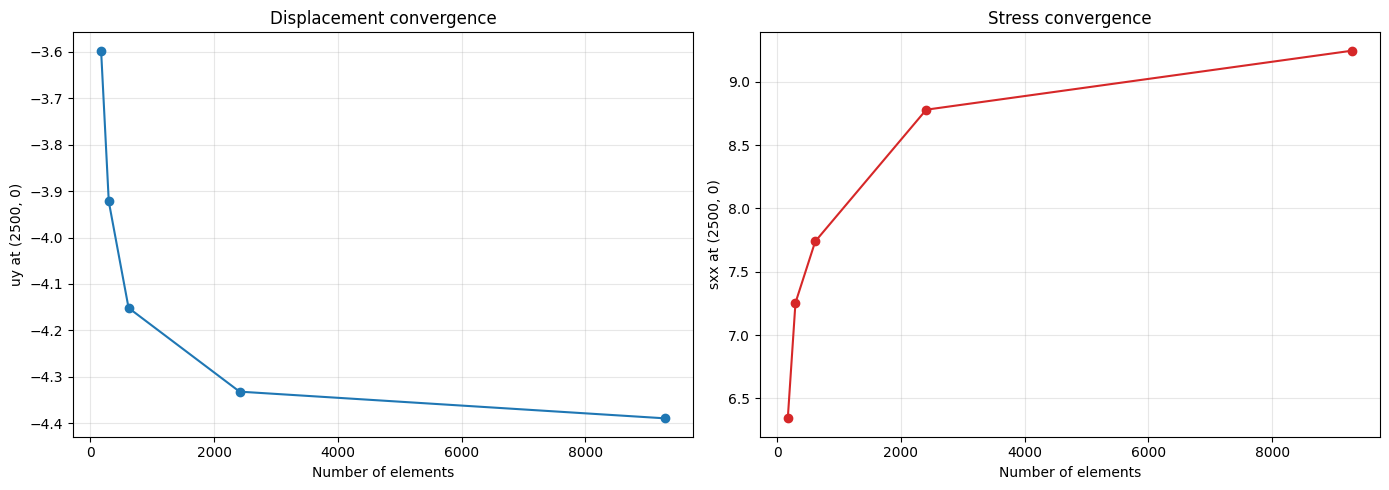

In [7]:
# Convergence plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

n_elems  = [r['n_elems'] for r in results]
uy_vals = [r['uy']      for r in results]
sxx_vals= [r['sxx']     for r in results]

ax1.plot(n_elems, uy_vals,  'o-', color='tab:blue')
ax1.set_xlabel('Number of elements')
ax1.set_ylabel('uy at (2500, 0)')
ax1.set_title('Displacement convergence')
ax1.grid(True, alpha=0.3)

ax2.plot(n_elems, sxx_vals, 'o-', color='tab:red')
ax2.set_xlabel('Number of elements')
ax2.set_ylabel('sxx at (2500, 0)')
ax2.set_title('Stress convergence')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

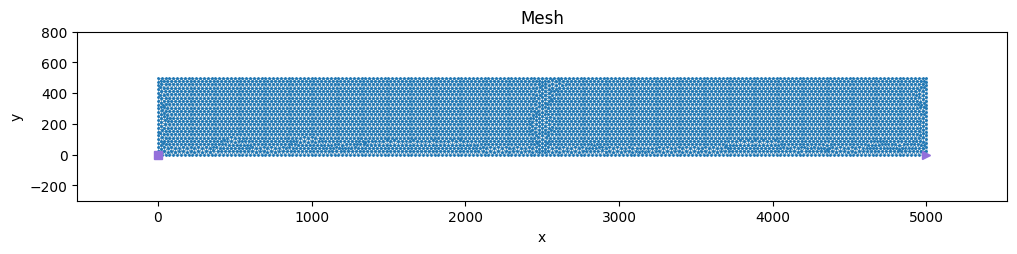

In [8]:
# Plot mesh
model.plot(
    step                = -1,
    show_node_labels    = False,
    show_element_labels = False,
    show_supports       = True,
    show_element_edges  = True,
    show_node_points    = True,
    figsize             = (12, 8),
)

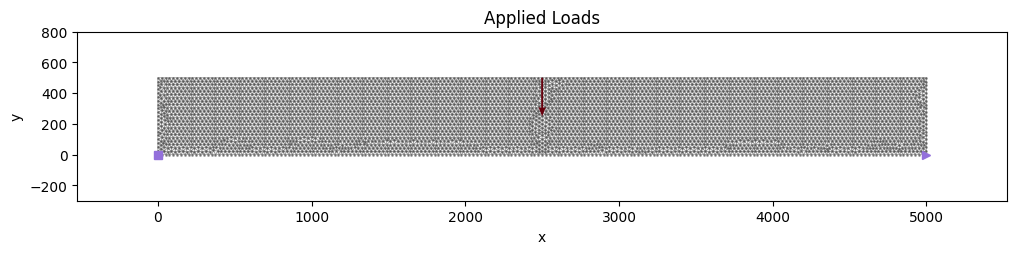

In [9]:
# Plot loads
model.plot_loads(
    show_element_edges = True,
    show_node_points   = True,
    show_supports      = True,
    figsize            = (12, 8),
)

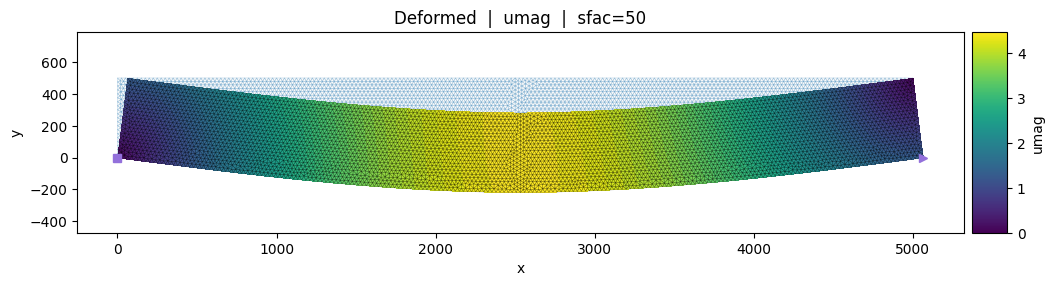

In [10]:
# Plot deformed
model.plot_deformed(
    sfac                = 50,
    step                = -1,
    component           = 'umag',   # 'ux', 'uy', 'umag'
    cmap                = 'viridis',
    show_element_edges  = True,
    show_supports       = True,
    figsize             = (12, 8),
)

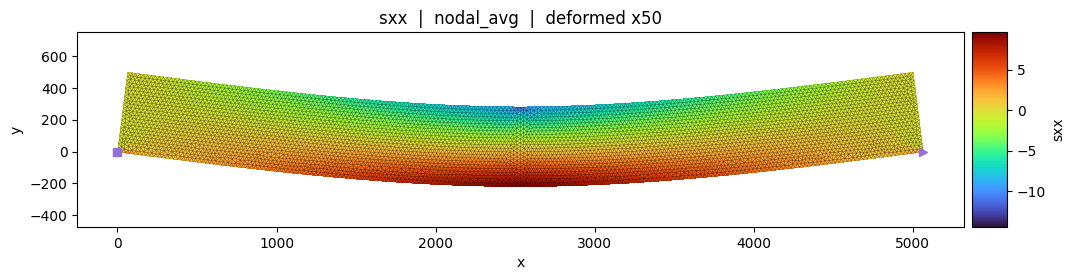

In [11]:
# Plot field
model.plot_field(
    component           = 'sxx',        # 'sxx','syy','sxy','vmis','s1','s2','exx','eyy','exy'
    source              = 'fem',
    step                = -1,
    result_type         = 'nodal_avg',  # 'nodal_avg' or 'element'
    deformed            = True,
    sfac                = 50,
    cmap                = 'turbo',
    show_element_edges  = True,
    show_supports       = True,
    figsize             = (12, 8),
)

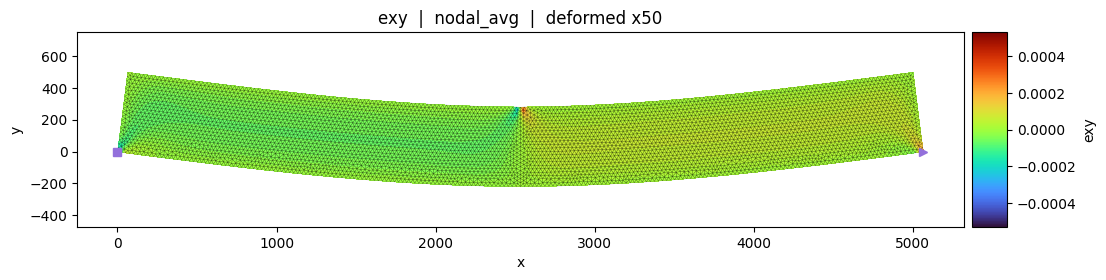

In [12]:
# Plot field
model.plot_field(
    component           = 'exy',        # 'sxx','syy','sxy','vmis','s1','s2','exx','eyy','exy'
    source              = 'fem',
    step                = -1,
    result_type         = 'nodal_avg',  # 'nodal_avg' or 'element'
    deformed            = True,
    sfac                = 50,
    cmap                = 'turbo',
    show_element_edges  = True,
    show_supports       = True,
    figsize             = (12, 8),
)

## 2nd order elements

In [14]:
lc_values = [200, 150, 100, 50, 25]
results   = {1: [], 2: []}

for order in [1, 2]:
    for lc in lc_values:
        # General model parameters
        L = 5000 
        H = 500  
        B = 300
        # lc = 100
        output_path = os.getcwd()
        mesh_name = 'calibrated_beam'
        output_file = os.path.join(output_path, mesh_name + '.msh')

        if not os.path.exists(output_path):
            os.makedirs(output_path)
            
            
        # Create a new GMSH model
        gmsh.initialize()
        gmsh.model.add(mesh_name)

        # Corner points
        p1 = gmsh.model.geo.addPoint(0,   0, 0, lc)
        p2 = gmsh.model.geo.addPoint(L,   0, 0, lc)
        p3 = gmsh.model.geo.addPoint(L,   H, 0, lc)
        p4 = gmsh.model.geo.addPoint(0,   H, 0, lc)

        # Mid points (bottom and top)
        p5 = gmsh.model.geo.addPoint(L/2, 0, 0, lc)
        p6 = gmsh.model.geo.addPoint(L/2, H, 0, lc)

        # Lines
        l1 = gmsh.model.geo.addLine(p1, p5)  # Bottom left
        l2 = gmsh.model.geo.addLine(p5, p2)  # Bottom right
        l3 = gmsh.model.geo.addLine(p2, p3)  # Right side
        l4 = gmsh.model.geo.addLine(p3, p6)  # Top right
        l5 = gmsh.model.geo.addLine(p6, p4)  # Top left
        l6 = gmsh.model.geo.addLine(p4, p1)  # Left side
        l7 = gmsh.model.geo.addLine(p5, p6)  # Center vertical

        # Surfaces
        c1 = gmsh.model.geo.addCurveLoop([l1,  l7, l5, l6])  # Left half
        s1 = gmsh.model.geo.addPlaneSurface([c1])

        c2 = gmsh.model.geo.addCurveLoop([l2, l3, l4, -l7])  # Right half
        s2 = gmsh.model.geo.addPlaneSurface([c2])

        gmsh.model.geo.synchronize()

        # Physical groups
        gmsh.model.addPhysicalGroup(2, [s1, s2], 201)
        gmsh.model.setPhysicalName(2, 201, "Beam")

        gmsh.model.addPhysicalGroup(0, [p1], 101)
        gmsh.model.setPhysicalName(0, 101, "Support_left")

        gmsh.model.addPhysicalGroup(0, [p2], 102)
        gmsh.model.setPhysicalName(0, 102, "Support_right")

        gmsh.model.addPhysicalGroup(0, [p6], 50)
        gmsh.model.setPhysicalName(0, 50, "Load")

        gmsh.model.geo.synchronize()

        def all_quads():
            gmsh.model.geo.synchronize()
            gmsh.option.setNumber("Mesh.RecombineAll", 1)
            gmsh.option.setNumber("Mesh.Algorithm", 8)
            gmsh.option.setNumber("Mesh.RecombinationAlgorithm", 2)
            gmsh.option.setNumber("Mesh.Smoothing", 100)
            gmsh.option.setNumber("Mesh.ElementOrder", 2)

        # all_quads()
        if order == 2:
            gmsh.option.setNumber("Mesh.ElementOrder", 2)

        # Generate the mesh
        gmsh.model.mesh.generate()
        # Save mesh to disk
        gmsh.write(output_file)
        # Open GMSH GUI
        # gmsh.fltk.run()
        # Write mesh file again (redundant)
        v = gmsh.write(output_file)
        # Close GMSH instance
        gmsh.finalize()



        # Build model
        mesh  = GMSHtools(output_file)
        # Build FEM model — applies BCs, builds elements, assembles load vector
        model = FEMModel(
            mesh                = mesh,
            section_dictionary  = section_dictionary,
            restrain_dictionary = restrain_dictionary,
            load_dictionary     = load_dictionary,
            element_class_map   = element_map,
            analysis_type       = 'planeStress',
            consistent_loads    = False,
            sampling_points     = 3,

            verbose=False,
        )


        # Solve — single step
        model.solve_static(
            n_steps=1, 
            load_factor=1.0,
            verbose = False,
        )

        # Extract results at x=2500, y=0
        node_tag  = model._find_nearest_node(2500, 0)
        node      = model.node_map[node_tag]
        node_idx  = np.where(model.node_tags == node_tag)[0][0]

        uy  = model.results_fem[-1].u[node.idx[1]]
        sxx = model.results_fem[-1].sigma_nodal[node_idx, 0]

        results[order].append({
            'lc'      : lc,
            'n_nodes' : len(mesh.nodes),
            'n_elems' : len(model.elements),
            'uy'      : uy,
            'sxx'     : sxx,
        })
                

  MESH SUMMARY

  === NODES ===  (116 total — showing first 3)
     Tag              x              y              z
--------------------------------------------------------------------------------
       1         0.0000         0.0000         0.0000
       2      5000.0000         0.0000         0.0000
       3      5000.0000       500.0000         0.0000
--------------------------------------------------------------------------------

  === PHYSICAL GROUPS ===  (4 total)
      ID    Dim   Name
--------------------------------------------------------------------------------
      50      0   'Load'
     101      0   'Support_left'
     102      0   'Support_right'
     201      2   'Beam'
--------------------------------------------------------------------------------

  === ELEMENTS ===  (4 groups)
      ID    Dim     Type   Nodes/el   N elements   Name
--------------------------------------------------------------------------------
      50      0       15          1            1  

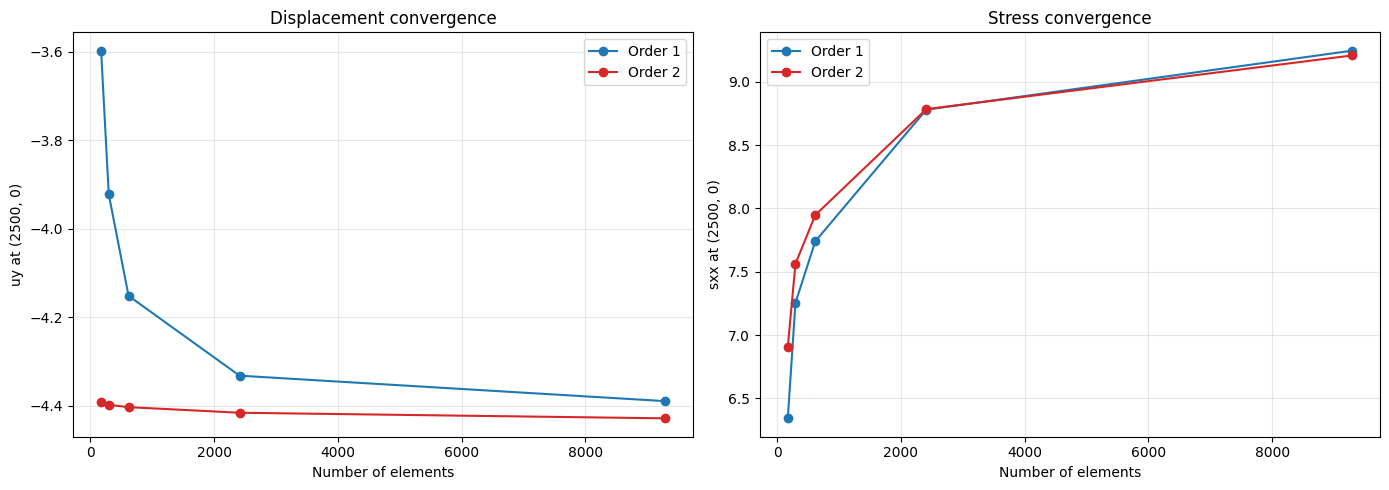

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for order, color, label in [(1, 'tab:blue', 'Order 1'), (2, 'tab:red', 'Order 2')]:
    n_elems  = [r['n_elems'] for r in results[order]]


    uy_vals  = [r['uy']      for r in results[order]]
    sxx_vals = [r['sxx']     for r in results[order]]
    ax1.plot(n_elems, uy_vals,  'o-', color=color, label=label)
    ax2.plot(n_elems, sxx_vals, 'o-', color=color, label=label)

for ax, ylabel, title in [
    (ax1, 'uy at (2500, 0)',  'Displacement convergence'),
    (ax2, 'sxx at (2500, 0)', 'Stress convergence'),
]:
    ax.set_xlabel('Number of elements')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [16]:
elem_idx = model._find_nearest_element(x=2500, y=0)
elem     = model.elements[elem_idx]
centroid = np.mean([n.coordinates for n in elem.nodes], axis=0)
print(f"Centroid: {centroid}")

Centroid: [2514.433757    6.100423]
